In [1]:

!pip install -q numpy pandas scikit-learn matplotlib seaborn tensorflow plotly joblib networkx python-dotenv
print("✅ Dependencies installed (or already present).")


✅ Dependencies installed (or already present).


## 1) Upload your dataset

In [2]:

from google.colab import files
uploaded = files.upload()
import os
if len(uploaded) == 1:
    name = list(uploaded.keys())[0]
    if name != 'cleaned_bank_transactions.csv':
        os.rename(name, 'cleaned_bank_transactions.csv')
        print(f"Renamed {name} -> cleaned_bank_transactions.csv")
else:
    print("Multiple files uploaded; expecting cleaned_bank_transactions.csv to be present.")


Saving cleaned_bank_transactions.csv to cleaned_bank_transactions.csv


## 2) Load & quick EDA

Shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IPAddress,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX001063,AC00456,68.10,2023-01-02 16:00:06,Debit,Milwaukee,D000235,94.227.164.192,M089,ATM,20,Student,47,1,1382.80,2024-11-04 08:10:15
1,TX001369,AC00316,487.16,2023-01-02 16:01:14,Credit,Los Angeles,D000361,156.96.135.18,M077,Branch,28,Student,84,1,321.21,2024-11-04 08:12:22
2,TX001623,AC00087,154.21,2023-01-02 16:01:26,Debit,Miami,D000549,190.251.45.32,M083,Online,46,Engineer,75,1,8045.77,2024-11-04 08:10:33
3,TX000983,AC00281,453.49,2023-01-02 16:06:29,Debit,Seattle,D000471,40.226.196.34,M088,Branch,66,Doctor,147,1,6366.43,2024-11-04 08:08:56
4,TX000877,AC00304,204.06,2023-01-02 16:07:17,Debit,Washington,D000685,150.231.20.169,M069,Online,77,Retired,159,1,4351.83,2024-11-04 08:07:22



Info:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IPAddress                   object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

Nulls per column:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IPAddress                  0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts          

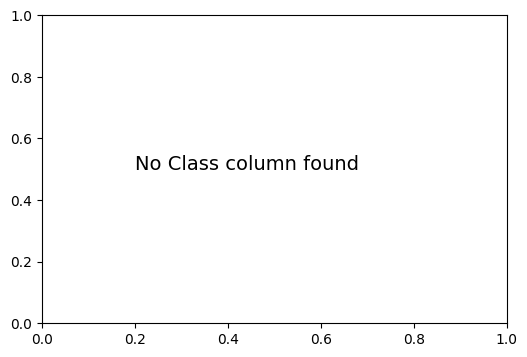

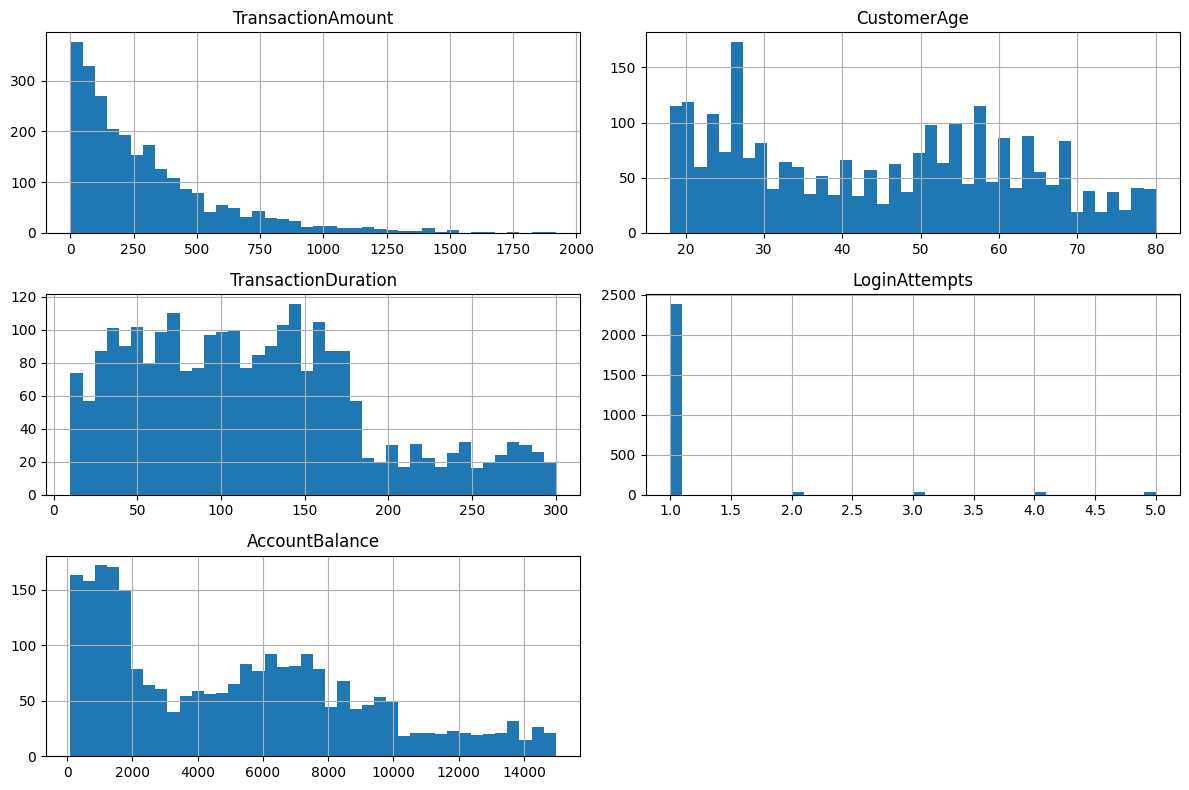

In [3]:

import pandas as pd, numpy as np

CSV_PATH = 'cleaned_bank_transactions.csv'
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nInfo:"); print(df.dtypes)
print("\nNulls per column:"); print(df.isna().sum().sort_values(ascending=False).head(20))

def find_col(keys):
    for c in df.columns:
        lc = c.lower()
        for k in keys:
            if k in lc: return c
    return None

COL_TXN_ID = find_col(['transactionid','txn','tx','trans_id','transid','id'])
COL_ACCOUNT = find_col(['account','acct','cust','customer'])
COL_MERCHANT = find_col(['merchant','mcc'])
COL_DEVICE = find_col(['device','imei'])
COL_TIME = find_col(['time','date','timestamp'])

print("\nGuessed columns:")
print("TransactionID:", COL_TXN_ID)
print("AccountID:", COL_ACCOUNT)
print("MerchantID:", COL_MERCHANT)
print("DeviceID:", COL_DEVICE)
print("Timestamp:", COL_TIME)

import matplotlib.pyplot as plt, seaborn as sns
plt.figure(figsize=(6,4))
if 'Class' in df.columns:
    sns.countplot(x=df['Class']); plt.title('Class Distribution (0=legit, 1=fraud)')
else:
    plt.text(0.2, 0.5, 'No Class column found', fontsize=14)
plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df[num_cols].hist(bins=40, figsize=(12,8)); plt.tight_layout(); plt.show()


## 3) Preprocess & Train Autoencoder (Unsupervised)

In [4]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib, tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np, pandas as pd, os

def preprocess(df, label_col='Class', drop_id_like=True, scale=True):
    d = df.copy(); y=None
    if label_col in d.columns:
        y = d[label_col].astype(int).values; d = d.drop(columns=[label_col])
    if drop_id_like:
        id_cols = [c for c in d.columns if any(k in c.lower() for k in ['id','txn','tx','transaction'])]
        d = d.drop(columns=id_cols, errors='ignore')
    cat_cols = d.select_dtypes(include=['object','category']).columns.tolist()
    if cat_cols: d = pd.get_dummies(d, columns=cat_cols, drop_first=True)
    feature_cols = d.columns.tolist()
    X = d.values.astype(float); scaler=None
    if scale:
        scaler = StandardScaler(); X = scaler.fit_transform(X)
    return X, y, feature_cols, scaler

X, y, FEATURES, SCALER = preprocess(df)
print("Processed shape:", X.shape)

def build_autoencoder(input_dim, encoding_dim=16, hidden=[128,64,32]):
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for h in hidden: x = layers.Dense(h, activation='relu')(x)
    z = layers.Dense(encoding_dim, activation='relu', name='latent')(x)
    x = z
    for h in reversed(hidden): x = layers.Dense(h, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    m = models.Model(inp, out, name='autoencoder')
    m.compile(optimizer=optimizers.Adam(1e-3), loss=losses.MeanSquaredError())
    return m

X_normal = X[y==0] if y is not None else X
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

ae = build_autoencoder(X.shape[1])
hist = ae.fit(X_train, X_train, validation_data=(X_val, X_val),
              epochs=50, batch_size=2048,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
              verbose=2)

os.makedirs('models', exist_ok=True)
ae.save('models/autoencoder.keras')
joblib.dump({'scaler': SCALER, 'features': FEATURES}, 'models/preproc.joblib')
print("✅ Saved model and preprocessing artifacts in /content/models")


Processed shape: (2512, 641)
Epoch 1/50
1/1 - 3s - 3s/step - loss: 1.0059 - val_loss: 0.9852
Epoch 2/50
1/1 - 0s - 334ms/step - loss: 1.0045 - val_loss: 0.9848
Epoch 3/50
1/1 - 0s - 165ms/step - loss: 1.0039 - val_loss: 0.9846
Epoch 4/50
1/1 - 0s - 330ms/step - loss: 1.0036 - val_loss: 0.9845
Epoch 5/50
1/1 - 0s - 313ms/step - loss: 1.0033 - val_loss: 0.9844
Epoch 6/50
1/1 - 0s - 198ms/step - loss: 1.0031 - val_loss: 0.9843
Epoch 7/50
1/1 - 0s - 247ms/step - loss: 1.0030 - val_loss: 0.9843
Epoch 8/50
1/1 - 0s - 218ms/step - loss: 1.0028 - val_loss: 0.9842
Epoch 9/50
1/1 - 0s - 295ms/step - loss: 1.0025 - val_loss: 0.9842
Epoch 10/50
1/1 - 0s - 311ms/step - loss: 1.0023 - val_loss: 0.9841
Epoch 11/50
1/1 - 0s - 271ms/step - loss: 1.0020 - val_loss: 0.9840
Epoch 12/50
1/1 - 0s - 247ms/step - loss: 1.0017 - val_loss: 0.9839
Epoch 13/50
1/1 - 0s - 220ms/step - loss: 1.0013 - val_loss: 0.9837
Epoch 14/50
1/1 - 0s - 137ms/step - loss: 1.0009 - val_loss: 0.9836
Epoch 15/50
1/1 - 0s - 144ms/st

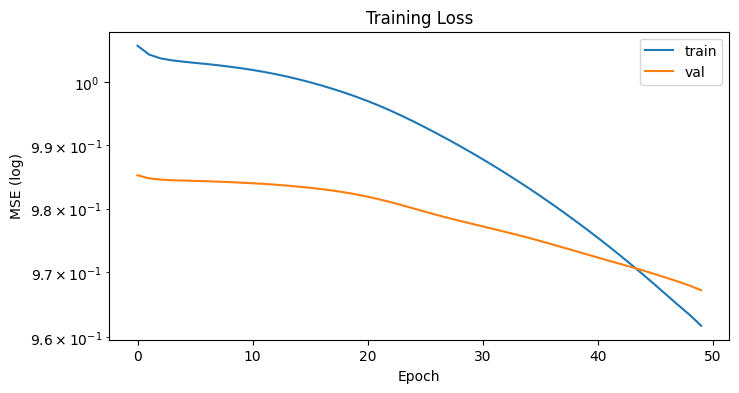

Chosen threshold (99th percentile of train errors): 3.720243448819377
Anomalies detected: 27 / 2512


In [5]:

import matplotlib.pyplot as plt, numpy as np, pandas as pd
from tensorflow.keras.models import load_model

plt.figure(figsize=(8,4))
plt.plot(hist.history['loss'], label='train'); plt.plot(hist.history['val_loss'], label='val')
plt.yscale('log'); plt.legend(); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE (log)')
plt.show()

ae_loaded = load_model('models/autoencoder.keras', compile=False)
recon_all = ae_loaded.predict(X, verbose=0)
mse_all = ((X - recon_all)**2).mean(axis=1)

train_recon = ae_loaded.predict(X_train, verbose=0)
train_errs = ((X_train - train_recon)**2).mean(axis=1)
threshold = float(np.percentile(train_errs, 99))
print("Chosen threshold (99th percentile of train errors):", threshold)

df_results = df.copy()
df_results['reconstruction_error'] = mse_all
df_results['anomaly'] = (df_results['reconstruction_error'] >= threshold).astype(int)

print("Anomalies detected:", int(df_results['anomaly'].sum()), "/", len(df_results))

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
if 'Class' in df_results.columns:
    y_true = df_results['Class'].astype(int).values
    y_pred = df_results['anomaly'].values
    print("AUC (errors):", roc_auc_score(y_true, mse_all))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))


## 4) Visualizations (errors, heatmap, category breakdown)

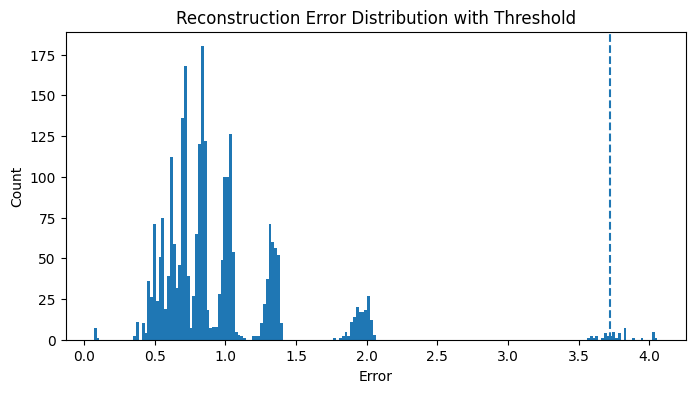

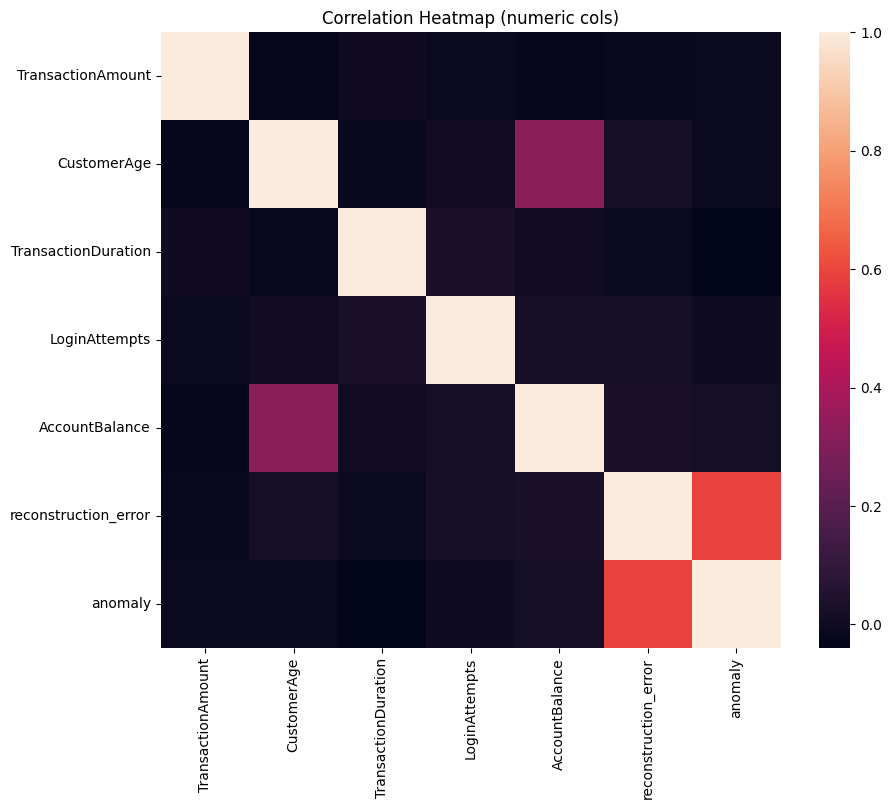

/tmp/ipython-input-3790037919.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate = df_results.groupby(COL_MERCHANT).apply(safe_rate).sort_values(ascending=False).head(15)


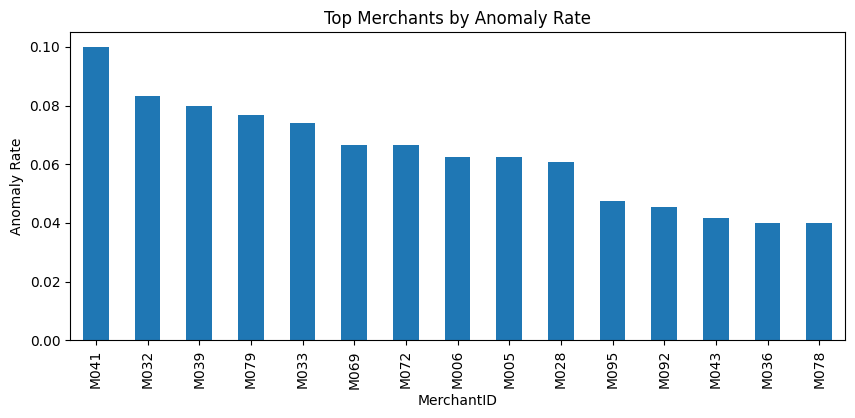

/tmp/ipython-input-3790037919.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate = df_results.groupby(COL_ACCOUNT).apply(safe_rate).sort_values(ascending=False).head(15)


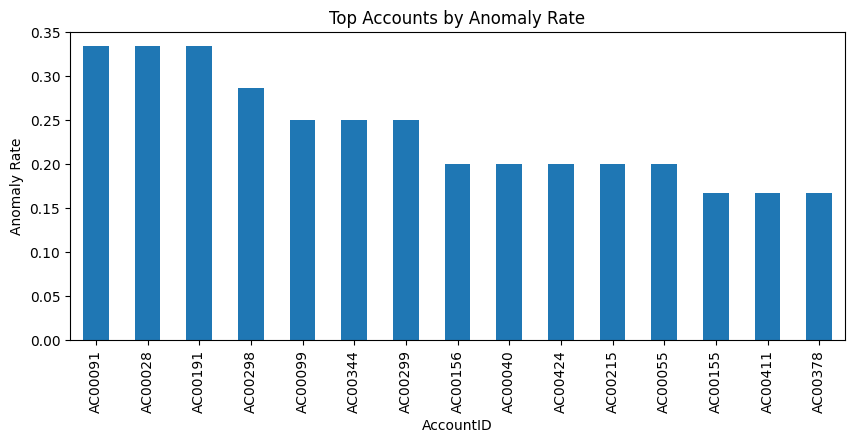

In [6]:

import matplotlib.pyplot as plt, seaborn as sns, numpy as np, pandas as pd

plt.figure(figsize=(8,4))
plt.hist(df_results['reconstruction_error'], bins=200)
plt.axvline(threshold, linestyle='--')
plt.title('Reconstruction Error Distribution with Threshold')
plt.xlabel('Error'); plt.ylabel('Count'); plt.show()

num_cols = df_results.select_dtypes(include=[np.number]).columns
if len(num_cols) > 1:
    plt.figure(figsize=(10,8))
    sns.heatmap(df_results[num_cols].corr(), annot=False)
    plt.title('Correlation Heatmap (numeric cols)'); plt.show()

def safe_rate(g): return (g['anomaly'].sum() / len(g)) if len(g) else 0

if COL_MERCHANT and COL_MERCHANT in df_results.columns:
    rate = df_results.groupby(COL_MERCHANT).apply(safe_rate).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10,4)); rate.plot(kind='bar')
    plt.title('Top Merchants by Anomaly Rate'); plt.ylabel('Anomaly Rate'); plt.show()

if COL_ACCOUNT and COL_ACCOUNT in df_results.columns:
    rate = df_results.groupby(COL_ACCOUNT).apply(safe_rate).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10,4)); rate.plot(kind='bar')
    plt.title('Top Accounts by Anomaly Rate'); plt.ylabel('Anomaly Rate'); plt.show()


## 5) Graph-Based Analysis (NetworkX — communities & centrality)

Graph nodes: 1276 edges: 4946


/tmp/ipython-input-2727983660.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


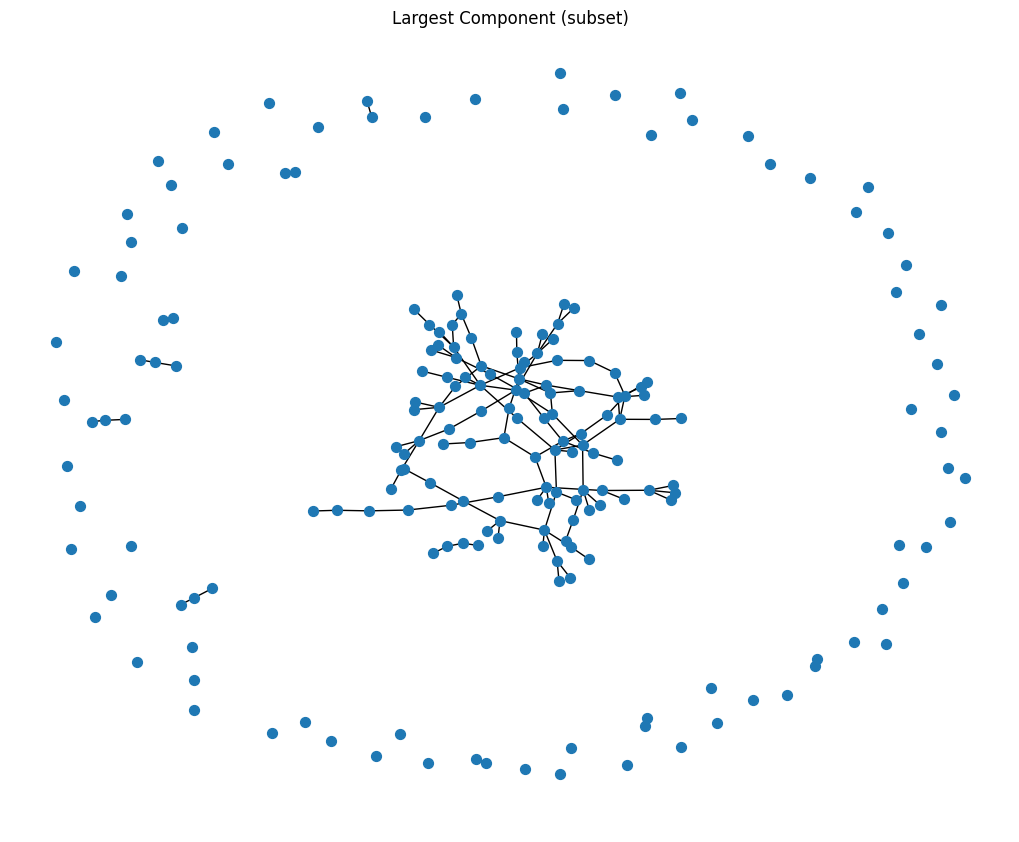

✅ Saved graph metrics & image in /content/graph_output


,node,degree,pagerank,component_id
24,M:M026,44,0.003871,0
223,M:M066,34,0.003063,0
82,M:M014,33,0.002962,0
75,M:M028,32,0.002851,0
377,M:M013,32,0.002806,0
55,M:M065,31,0.002716,0
233,M:M005,31,0.002787,0
465,M:M001,31,0.002734,0
197,M:M002,31,0.002679,0
41,M:M068,31,0.002773,0


In [7]:

import networkx as nx, pandas as pd, os, matplotlib.pyplot as plt

def build_graph(df, account_col=None, merchant_col=None, device_col=None, txn_id_col=None):
    G = nx.Graph()
    for _, r in df.iterrows():
        acc = r.get(account_col) if account_col else None
        mer = r.get(merchant_col) if merchant_col else None
        dev = r.get(device_col) if device_col else None
        tx  = r.get(txn_id_col) if txn_id_col else None
        if acc is not None and mer is not None:
            G.add_edge(f"A:{acc}", f"M:{mer}", key=tx, label="txn")
        if acc is not None and dev is not None:
            G.add_edge(f"A:{acc}", f"D:{dev}", key=tx, label="uses")
    return G

G = build_graph(df_results, COL_ACCOUNT, COL_MERCHANT, COL_DEVICE, COL_TXN_ID)
print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

deg = dict(G.degree())
pagerank = nx.pagerank(G, alpha=0.85) if G.number_of_nodes() < 50000 else {n: None for n in G.nodes()}
components = list(nx.connected_components(G))

metrics = []
for n in G.nodes():
    comp_id = next((i for i,c in enumerate(components) if n in c), None)
    metrics.append({'node': n, 'degree': deg.get(n,0), 'pagerank': pagerank.get(n, None), 'component_id': comp_id})
metrics_df = pd.DataFrame(metrics).sort_values(['degree'], ascending=False)

os.makedirs('graph_output', exist_ok=True)
metrics_df.to_csv('graph_output/network_metrics.csv', index=False)

if G.number_of_nodes() > 0:
    largest_cc = max(components, key=len)
    H = G.subgraph(list(largest_cc)[:200]).copy()
    plt.figure(figsize=(10,8))
    pos = nx.spring_layout(H, seed=42)
    nx.draw(H, pos, node_size=50, with_labels=False)
    plt.title("Largest Component (subset)")
    plt.tight_layout()
    plt.savefig('graph_output/graph_overview.png', dpi=150)
    plt.show()

print("✅ Saved graph metrics & image in /content/graph_output")
display(metrics_df.head(20))


## 6) Real-Time Fraud Monitoring (Simulation in Colab) + Email Alerts

In [9]:

import os, time, smtplib
from email.mime.text import MIMEText
from dotenv import load_dotenv
import numpy as np, pandas as pd

load_dotenv()

SMTP_HOST = os.getenv("SMTP_HOST", "smtp.gmail.com")
SMTP_PORT = int(os.getenv("SMTP_PORT", "587"))
ALERT_SENDER = os.getenv("ALERT_EMAIL_SENDER", "")
ALERT_PASSWORD = os.getenv("ALERT_EMAIL_APP_PASSWORD", "")
ALERT_RECIPIENTS = [e.strip() for e in os.getenv("ALERT_EMAIL_RECIPIENTS","").split(",") if e.strip()]
SEND_EMAILS = False  # set True to actually send emails

def send_alert(subject, body, recipients=None):
    if not SEND_EMAILS:
        print("\n[DRY-RUN ALERT]\n", subject, "\n", body[:500], "\n")
        return
    recips = recipients or ALERT_RECIPIENTS
    if not (ALERT_SENDER and ALERT_PASSWORD and recips):
        print("Email not configured. Set ALERT_EMAIL_* in env and set SEND_EMAILS=True.")
        return
    msg = MIMEText(body, "plain"); msg["From"]=ALERT_SENDER; msg["To"]=", ".join(recips); msg["Subject"]=subject
    with smtplib.SMTP(SMTP_HOST, SMTP_PORT) as server:
        server.ehlo(); server.starttls(); server.login(ALERT_SENDER, ALERT_PASSWORD); server.sendmail(ALERT_SENDER, recips, msg.as_string())
    print(f"✅ Alert sent to {recips}")

def simulate_streaming(df_source: pd.DataFrame, batch_size=500, percentile=99.0, sleep_sec=0.0):
    os.makedirs('stream_output', exist_ok=True)
    n = len(df_source); batches = (n + batch_size - 1) // batch_size
    print(f"Simulating {batches} batches of ~{batch_size} rows...")
    total_anoms = 0
    for b in range(batches):
        start, end = b*batch_size, min((b+1)*batch_size, n)
        batch = df_source.iloc[start:end].copy()
        Xb, _, _, _ = preprocess(batch, label_col='Class', drop_id_like=True, scale=True)
        recon = ae_loaded.predict(Xb, verbose=0)
        mse_b = ((Xb - recon)**2).mean(axis=1)
        batch['reconstruction_error'] = mse_b
        thr = float(np.percentile(mse_b, percentile))
        batch['anomaly'] = (batch['reconstruction_error'] >= thr).astype(int)
        total_anoms += int(batch['anomaly'].sum())
        batch.to_csv(f'stream_output/scored_batch_{b}.csv', index=False)
        if batch['anomaly'].any():
            anoms = batch[batch['anomaly']==1].copy()
            anoms.to_csv(f'stream_output/anomalies_batch_{b}.csv', index=False)
            preview = anoms.nlargest(5, 'reconstruction_error').to_string(index=False)
            body = f"Detected {len(anoms)} anomalies in batch {b} (rows {start}..{end}).\n\nTop 5:\n{preview}"
            send_alert(subject=f"[FRAUD ALERT] {len(anoms)} anomalies in batch {b}", body=body)
        print(f"Batch {b+1}/{batches} processed. Anomalies so far: {total_anoms}")
        if sleep_sec > 0: time.sleep(sleep_sec)
    print(f"✅ Streaming simulation complete. Total anomalies: {total_anoms}")

simulate_streaming(df, batch_size=500, percentile=99.0, sleep_sec=0.0)


Simulating 6 batches of ~500 rows...


InvalidArgumentError: Graph execution error:

Detected at node autoencoder_1/dense_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-pa

## 7) Adaptive Learning (Threshold Recalibration & Optional Retrain)

In [10]:

import glob
from sklearn.model_selection import train_test_split

def recalibrate_threshold_from_outputs(pattern='stream_output/scored_batch_*.csv', percentile=99.5):
    files = sorted(glob.glob(pattern))
    if not files:
        print("No scored batches found."); return None
    errs = []
    for f in files[-20:]:
        dfb = pd.read_csv(f)
        if 'reconstruction_error' in dfb.columns:
            errs.extend(dfb['reconstruction_error'].values.tolist())
    if not errs:
        print("No errors found."); return None
    thr = float(np.percentile(errs, percentile))
    print(f"New threshold (p{percentile}): {thr:.6f}"); return thr

def optional_retrain(train_csv='cleaned_bank_transactions.csv', epochs=30):
    base = pd.read_csv(train_csv).copy()
    if 'Class' in base.columns:
        base = base[base['Class']==0].drop(columns=['Class'])
    Xr, _, feats, sc = preprocess(base, label_col=None, drop_id_like=True, scale=True)
    Xtr, Xva = train_test_split(Xr, test_size=0.2, random_state=42)
    m = build_autoencoder(Xr.shape[1])
    m.fit(Xtr, Xtr, validation_data=(Xva, Xva), epochs=epochs, batch_size=2048, verbose=2)
    m.save('models/autoencoder.keras')
    joblib.dump({'scaler': sc, 'features': feats}, 'models/preproc.joblib')
    print("✅ Retrained model saved.")

_ = recalibrate_threshold_from_outputs(percentile=99.5)
# optional_retrain(epochs=20)  # uncomment to retrain


No scored batches found.


## 8) Export for Power BI (CSV + README)

In [11]:

import os, pandas as pd
os.makedirs('powerbi', exist_ok=True)
df_results.to_csv('powerbi/full_scored_snapshot.csv', index=False)
print("Saved snapshot to powerbi/full_scored_snapshot.csv")

readme = '''# Power BI — Multi-Tab Fraud Report

Create a PBIX with these tabs:
1. **Overview** — KPI cards (Anomalies Count), histogram of reconstruction_error, anomalies over time.
2. **Real-Time Alerts** — table from `stream_output/anomalies_batch_*.csv`.
3. **Graph Network** — table from `graph_output/network_metrics.csv` and image `graph_overview.png`.
4. **Model Performance** — Precision/Recall/F1 if labels exist.

## Data Sources
- Folder: `stream_output/` (both scored and anomalies CSVs)
- File: `graph_output/network_metrics.csv`
- File: `powerbi/full_scored_snapshot.csv`
- Optional base: `cleaned_bank_transactions.csv`

## DAX Measures
Anomalies Count = COUNTROWS(Anomalies)
Avg Error = AVERAGE(Scored[reconstruction_error])
TP = COUNTROWS(FILTER(Scored, Scored[anomaly] = 1 && Scored[Class] = 1))
FP = COUNTROWS(FILTER(Scored, Scored[anomaly] = 1 && Scored[Class] = 0))
FN = COUNTROWS(FILTER(Scored, Scored[anomaly] = 0 && Scored[Class] = 1))
TN = COUNTROWS(FILTER(Scored, Scored[anomaly] = 0 && Scored[Class] = 0))
Fraud Precision = DIVIDE([TP], [TP] + [FP])
Fraud Recall = DIVIDE([TP], [TP] + [FN])
F1 Score = DIVIDE(2 * [Fraud Precision] * [Fraud Recall], [Fraud Precision] + [Fraud Recall])

## Power Query (M) — Combine anomalies folder
let
  Source = Folder.Files("C:\\path\\to\\stream_output"),
  Filtered = Table.SelectRows(Source, each Text.StartsWith([Name], "anomalies_batch_") and Text.EndsWith([Extension], ".csv")),
  Transform = Table.TransformColumns(Filtered, {{"Content", Csv.Document, type table}}),
  Expanded = Table.ExpandTableColumn(Transform, "Content", Table.ColumnNames(Transform{0}[Content]))
in
  Expanded
'''
open('powerbi/README_powerbi.md','w').write(readme)
print("✅ Wrote powerbi/README_powerbi.md")


Saved snapshot to powerbi/full_scored_snapshot.csv
✅ Wrote powerbi/README_powerbi.md
